# E-Commerce Sales Analytics
## Portfolio Project 1

**Stack:** Google BigQuery · Python (pandas, matplotlib, seaborn) · Tableau Public  

**Період:** 8.06.2026 - ...

**Мета:** Вивантажити, дослідити та статистично проаналізувати дані продажів інтернет-магазину, а потім візуалізувати ключові інсайти в інтерактивному дашборді Tableau.

If work locally - run this in terminal
gcloud auth application-default login
pip install google-cloud-bigquery
pip install db-dtypes
pip install matplotlib
pip install seaborn

In [78]:
from google.cloud import bigquery
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


os.environ.pop('GOOGLE_APPLICATION_CREDENTIALS', None)

try:
    from google.colab import auth
    
    auth.authenticate_user()
    print('Running in Google Colab')
    
except ModuleNotFoundError:
    print('Running locally in VS Code / Jupyter')
    print('Python:', sys.executable)

project_id = 'data-analytics-mate'
client = bigquery.Client(project=project_id)

print('BigQuery client created')

Running locally in VS Code / Jupyter
Python: /Users/apple/Documents/gitProjects/online_store_sales_analysis/.venv/bin/python


/Users/apple/Documents/gitProjects/online_store_sales_analysis/.venv/lib/python3.10/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


BigQuery client created


In [79]:
query = """
SELECT
  o.ga_session_id,        -- ідентифікатор сесії --
  o.item_id,              -- ідентифікатор товару --
  s.date,                 -- дата замовлення --
  sp.continent,           -- континент --
  sp.country,             -- країна --
  sp.device,              -- девайс --
  sp.browser,             -- браузер --
  sp.mobile_model_name,   -- назва моделі пристрою --
  sp.operating_system,    -- операційна система --
  sp.language,            -- мова браузера --
  sp.medium,              -- інформація про джерело трафіку --
  sp.channel,             -- канал трафіку --
  a_s.account_id,         -- дентифікатор зареєстрованого користувача --
  a.is_verified,          -- чи підтвердив користувач свій email --
  a.is_unsubscribed,      -- чи відписався користувач від розсилки --
  p.category,             -- категорія товару --
  p.name,                 -- назва товару --
  p.price,                -- ціна --
  p.short_description     -- короткий опис товару --
FROM `data-analytics-mate.DA.order` AS o
JOIN `data-analytics-mate.DA.session` AS s
  ON o.ga_session_id = s.ga_session_id
JOIN `data-analytics-mate.DA.session_params` AS sp
  ON o.ga_session_id = sp.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account_session` AS a_s
  ON o.ga_session_id = a_s.ga_session_id
LEFT JOIN `data-analytics-mate.DA.account` AS a
  ON a_s.account_id = a.id
JOIN `data-analytics-mate.DA.product` AS p
  ON o.item_id = p.item_id
  """
df = client.query(query).to_dataframe()

/Users/apple/Documents/gitProjects/online_store_sales_analysis/.venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [80]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33538 entries, 0 to 33537
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ga_session_id      33538 non-null  Int64  
 1   item_id            33538 non-null  Int64  
 2   date               33538 non-null  dbdate 
 3   continent          33538 non-null  object 
 4   country            33538 non-null  object 
 5   device             33538 non-null  object 
 6   browser            33538 non-null  object 
 7   mobile_model_name  33538 non-null  object 
 8   operating_system   33538 non-null  object 
 9   language           22531 non-null  object 
 10  medium             33538 non-null  object 
 11  channel            33538 non-null  object 
 12  account_id         2781 non-null   Int64  
 13  is_verified        2781 non-null   Int64  
 14  is_unsubscribed    2781 non-null   Int64  
 15  category           33538 non-null  object 
 16  name               335

,ga_session_id,item_id,date,continent,country,device,browser,mobile_model_name,operating_system,language,medium,channel,account_id,is_verified,is_unsubscribed,category,name,price,short_description
0,7799937037,91415,2020-11-06,Europe,Slovakia,mobile,Chrome,<Other>,Web,fr,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
1,4020421879,91415,2020-11-10,Americas,United States,desktop,Chrome,Safari,Macintosh,en,(none),Direct,653378,1,0,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
2,6717382496,91415,2020-11-24,Americas,United States,desktop,Chrome,Chrome,Web,en-us,referral,Social Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
3,2093497337,91415,2020-11-26,Americas,United States,desktop,Chrome,Chrome,Web,en-us,(none),Direct,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"
4,9506718330,91415,2020-12-03,Europe,Spain,desktop,Chrome,ChromeBook,<Other>,en-us,referral,Paid Search,<NA>,<NA>,<NA>,Children's furniture,TROFAST,5.0,"Lid, 20x28 cm"


In [81]:
unique_sessions = df['ga_session_id'].nunique()
date_min = df['date'].min()
date_max = df['date'].max()

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(0)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_count', ascending=False)

print(f'Унікальних сесій:   {unique_sessions:,}')
print(f'Дата від:           {date_min}')
print(f'Дата до:            {date_max}')
print()
print('Пропущені значення по колонках:')
print(missing_df)

Унікальних сесій:   33,538
Дата від:           2020-11-01
Дата до:            2021-01-27

Пропущені значення по колонках:
                 missing_count  missing_%
account_id               30757       92.0
is_verified              30757       92.0
is_unsubscribed          30757       92.0
language                 11007       33.0


# Короткий опис датасету

Датасет зібрано з BigQuery і є результатом з'єднання п'яти таблиць: замовлення (`order`), сесії (`session`), параметри сесій (`session_params`), акаунти (`account`) та товари (`product`). Кожен рядок відповідає одному проданому товару в межах однієї сесії.

---

## Загальна структура

| Параметр | Значення |
|---|---|
| Кількість рядків | 33 538 |
| Кількість колонок | 19 |
| Унікальних сесій | 33 538 *(кожна сесія - одна покупка)* |
| Часовий діапазон | 01.11.2020 - 27.01.2021 |
| Тривалість | ≈ 3 місяці *(Black Friday + Різдво + Новий рік)* |

---

## Типи колонок

### Числові - 6 колонок
| Колонка | Тип | Примітка |
|---|---|---|
| `ga_session_id` | Int64 | Ідентифікатор сесії (ключ) |
| `item_id` | Int64 | Ідентифікатор товару (ключ) |
| `account_id` | Int64 | ID зареєстрованого користувача |
| `is_verified` | Int64 | Бінарний прапор (0/1) |
| `is_unsubscribed` | Int64 | Бінарний прапор (0/1) |
| `price` | float64 | Ціна товару |

### Категоріальні - 12 колонок
`continent`, `country`, `device`, `browser`, `mobile_model_name`, `operating_system`, `language`, `medium`, `channel`, `category`, `name`, `short_description`

### Дата - 1 колонка
`date` (тип `dbdate`)

---

## Пропущені значення

| Колонка | Пропущено | % від усіх |
|---|---|---|
| `account_id` | 30 757 | **92%** |
| `is_verified` | 30 757 | **92%** |
| `is_unsubscribed` | 30 757 | **92%** |
| `language` | 11 007 | **33%** |

**Причини:**

- `account_id` / `is_verified` / `is_unsubscribed` - ці колонки підтягуються через `LEFT JOIN` до таблиці акаунтів. 92% покупок здійснено **незареєстрованими користувачами** - для них записів в таблиці `account` немає, тому всі три пов'язані поля `NULL`.

- `language` - мову браузера не вдалося визначити для 33% сесій.

---

## Елементи некоректних даних


In [82]:
print(df['mobile_model_name'].value_counts())

mobile_browser_diff = df.loc[df['mobile_model_name'] != df['browser'], ['mobile_model_name', 'browser']]

mobile_browser_diff.head(25)

mobile_model_name
Chrome        9359
Safari        6833
iPhone        6819
<Other>       6801
ChromeBook    1877
Edge           741
iPad           456
Firefox        430
Pixel 4 XL     117
Pixel 3        105
Name: count, dtype: int64


,mobile_model_name,browser
0,<Other>,Chrome
1,Safari,Chrome
4,ChromeBook,Chrome
6,iPhone,Safari
7,Safari,Chrome
10,<Other>,Chrome
11,Safari,Chrome
14,iPhone,Safari
15,iPhone,Safari
16,<Other>,Chrome


Під час перевірки даних було виявлено, що в колонці `mobile_model_name` частина значень - моделі пристроїв (`iPhone`, `iPad`, `Pixel 3`, `Pixel 4 XL`), також зустрічаються значення браузерів або платформ (`Chrome`, `Safari`, `Edge`, `Firefox`, `ChromeBook`).

Додаткова перевірка пари колонок `mobile_model_name` та `browser` показала, що ці поля не завжди дублюють одне одного. Наприклад, можуть зустрічатися комбінації `mobile_model_name = Safari` та `browser = Chrome`.

Це **очікувана поведінка GA4**, а не помилка даних. Поле `device_model` у GA4 фізично не збирається для Desktop-пристроїв. Тому для Desktop-рядків у `mobile_model_name` автоматично підставляється значення з браузерного user-agent. Комбінація `mobile_model_name = Safari` + `browser = Chrome` описує можливо браузер за замовчуванням у системі та фактично використаний браузер під час сесії.

Окремо: `ChromeBook` - це модель ноутбуку.

**Висновок щодо використання колонки:**
- `mobile_model_name` надійна лише для `device` mobile та tablet.
- Для Desktop-рядків містить назву браузера.

---

**Спостереження:** Датасет охоплює **святковий сезон** (листопад-січень), що безпосередньо впливає на обсяги продажів. 92% покупок - гостьові, що ускладнює персоналізований аналіз поведінки.

---
# Аналіз продажів

## 1. Географія продажів

In [212]:
continent_sales = df.groupby('continent')['price'].sum().sort_values(ascending=False)

print('Топ-3 континенти за сумою продажів (у доларах та % від загальної суми):')
for index, (continent, value) in enumerate(continent_sales.head(3).items(), start=1):
    print(f'{index:>2}. {continent:<10} ${value:>10,.0f} ({value / df["price"].sum() * 100:.1f}%)')

print('-'*80)
print()

continent_orders = df.groupby('continent')['ga_session_id'].nunique().sort_values(ascending=False)

print('Топ-3 континенти за кількістю замовлень (у сесіях та % від загальної кількості):')
for index, (continent, value) in enumerate(continent_orders.head(3).items(), start=1):
    print(f'{index:>2}. {continent:<10} {value:>10,} замовлень ({value / unique_sessions * 100:.1f}%)')

print('-'*80)
print()

country_sales = df.groupby('country')['price'].sum().sort_values(ascending=False).head(5)

print('Топ-5 країн за сумою продажів (у доларах та % від загальної суми):')
for index, (country, value) in enumerate(country_sales.items(), start=1):
    print(f'{index:>2}. {country:<20} ${value:>10,.0f} ({value / df["price"].sum() * 100:.1f}%)')

print('-'*80)
print()

country_orders = df.groupby('country')['ga_session_id'].count().sort_values(ascending=False).head(5)

print('Топ-5 країн за кількістю замовлень (у сесіях та % від загальної кількості):')
for index, (country, value) in enumerate(country_orders.items(), start=1):
    print(f'{index:>2}. {country:<20} {value:>10,} замовлень ({value / len(df) * 100:.1f}%)')
# print(f'{index:>2}. {category:<35} ${value:>10,.0f} ({value / us_total_sales * 100:.1f}%)')

Топ-3 континенти за сумою продажів (у доларах та % від загальної суми):
 1. Americas   $17,665,280 (55.3%)
 2. Asia       $ 7,601,298 (23.8%)
 3. Europe     $ 5,934,624 (18.6%)
--------------------------------------------------------------------------------

Топ-3 континенти за кількістю замовлень (у сесіях та % від загальної кількості):
 1. Americas       18,553 замовлень (55.3%)
 2. Asia            7,950 замовлень (23.7%)
 3. Europe          6,261 замовлень (18.7%)
--------------------------------------------------------------------------------

Топ-5 країн за сумою продажів (у доларах та % від загальної суми):
 1. United States        $13,943,554 (43.6%)
 2. India                $ 2,809,762 (8.8%)
 3. Canada               $ 2,437,921 (7.6%)
 4. United Kingdom       $   938,318 (2.9%)
 5. France               $   710,693 (2.2%)
--------------------------------------------------------------------------------

Топ-5 країн за кількістю замовлень (у сесіях та % від загальної кількості):


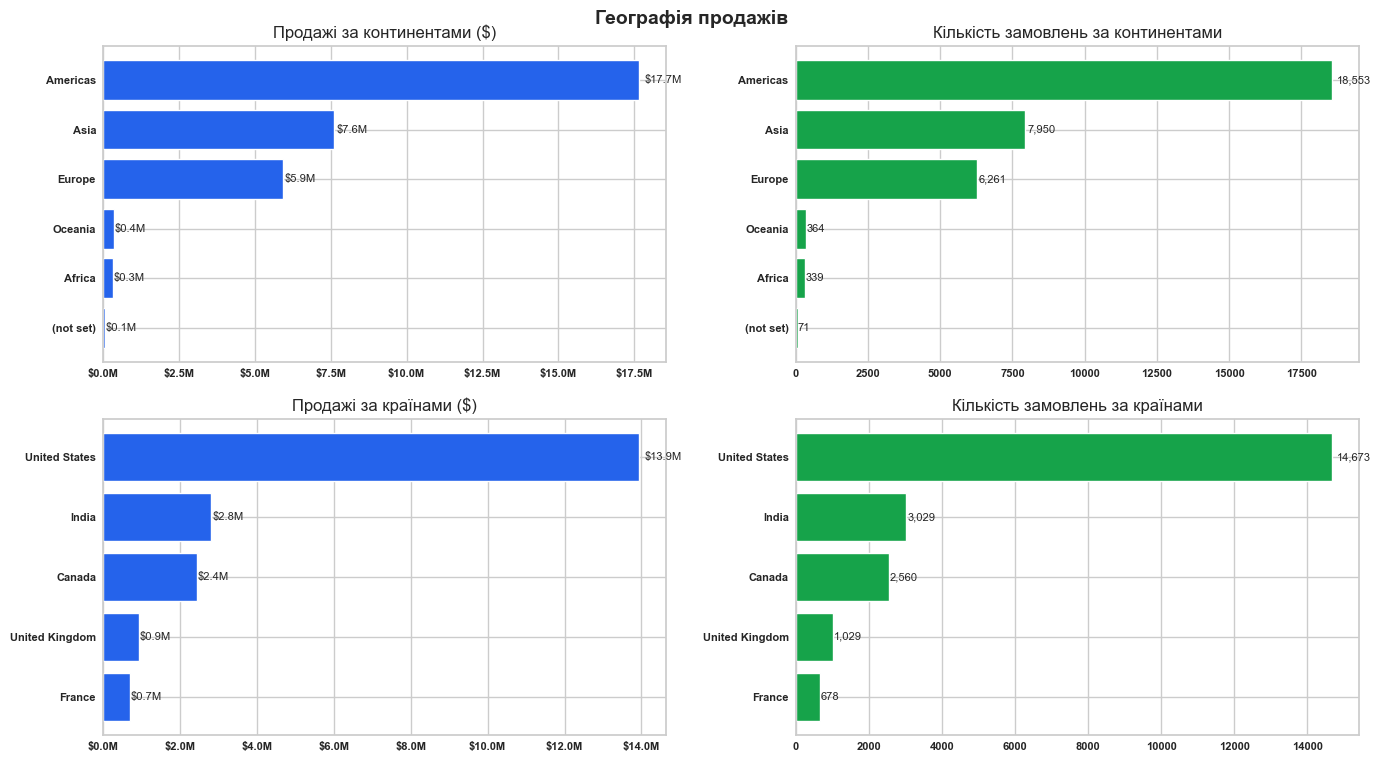

In [194]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

ACCENT = '#2563EB'
GREEN  = '#16A34A'

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Географія продажів', fontsize=14, fontweight='bold', y=0.95)

# продажі за континентами
ax = axes[0, 0]
bars = ax.barh(continent_sales.index[::-1], continent_sales.values[::-1], color=ACCENT)
ax.set_title('Продажі за континентами ($)')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, continent_sales.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=8)


# замовлення за континентами
ax = axes[0, 1]
bars = ax.barh(continent_orders.index[::-1], continent_orders.values[::-1], color=GREEN)
ax.set_title('Кількість замовлень за континентами')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

for bar, val in zip(bars, continent_orders.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
    

# продажі за країнами
ax = axes[1, 0]
bars = ax.barh(country_sales.index[::-1], country_sales.values[::-1], color=ACCENT)
ax.set_title('Продажі за країнами ($)')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
for bar, val in zip(bars, country_sales.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'${val/1e6:.1f}M', va='center', fontsize=8)
    

# замовлення за країнами
ax = axes[1, 1]
bars = ax.barh(country_orders.index[::-1], country_orders.values[::-1], color=GREEN)
ax.set_title('Кількість замовлень за країнами')

ax.tick_params(axis='x', labelsize=8, pad = -1)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')
ax.tick_params(axis='y', labelsize=8, pad = -1)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')

for bar, val in zip(bars, country_orders.values[::-1]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('images/sales_by_continents_countries.png', bbox_inches='tight')
plt.show()

**Висновок:** основним ринком компанії є **Americas** - цей континент забезпечує **55.3%** загальної суми продажів та **55.3%** усіх замовлень. Серед країн безумовним лідером є **United States**, на які припадає **43.6%** продажів та **43.8%** замовлень. Також до топ-5 країн входять **Canada** із часткою **7.6%** у продажах та **7.6%** у замовленнях.

Друге місце займає **Asia**, частка якої становить **23.8%** від суми продажів та **23.7%** від кількості замовлень. Ключовою країною на цьому континенті є **India**, яка забезпечує **8.8%** продажів та **9.0%** замовлень.

Третє місце посідає **Europe** із часткою **18.6%** у продажах та **18.7%** у кількості замовлень. Серед європейських країн у топ-5 представлені **United Kingdom** - **2.9%** продажів і **3.1%** замовлень, а також **France** - **2.2%** продажів і **2.0%** замовлень.

Отже, компанія найбільше залежить від ринку **Americas**, особливо від **United States**. Водночас інші країни з топ-5 - **India**, **Canada**, **United Kingdom** та **France** - також формують важливу частину продажів і замовлень компанії.


## 2. Категорії товарів

In [184]:
total_sales = df['price'].sum()

df_us = df[df['country'] == 'United States']
us_total_sales = df_us['price'].sum()

top10_categories_global = df.groupby('category')['price'].sum().sort_values(ascending=False).head(10)

print('Топ-10 категорій за сумою продажів (у доларах та % від загальної суми):')

for index, (category, value) in enumerate(top10_categories_global.items(), start=1):
    print(f'{index:>2}. {category:<35} $ {value:>10,.0f} ({value / total_sales * 100:.1f}%)')

print('-'*90)
print()

top10_categories_us = df[df['country'] == 'United States'].groupby('category')['price'].sum().sort_values(ascending=False).head(10)

print('Топ-10 категорій в United States за сумою продажів (у доларах та % від суми продажів в US):')
for index, (category, value) in enumerate(top10_categories_us.items(), start=1):
    print(f'{index:>2}. {category:<35} ${value:>10,.0f} ({value / us_total_sales * 100:.1f}%)')

print('-'*90)

Топ-10 категорій за сумою продажів (у доларах та % від загальної суми):
 1. Sofas & armchairs                   $  8,388,254 (26.2%)
 2. Chairs                              $  6,147,749 (19.2%)
 3. Beds                                $  4,919,725 (15.4%)
 4. Bookcases & shelving units          $  3,640,818 (11.4%)
 5. Cabinets & cupboards                $  2,336,500 (7.3%)
 6. Outdoor furniture                   $  2,142,222 (6.7%)
 7. Tables & desks                      $  1,790,308 (5.6%)
 8. Chests of drawers & drawer units    $    906,562 (2.8%)
 9. Bar furniture                       $    735,503 (2.3%)
10. Children's furniture                $    467,697 (1.5%)
------------------------------------------------------------------------------------------

Топ-10 категорій в United States за сумою продажів (у доларах та % від суми продажів в US):
 1. Sofas & armchairs                   $ 3,707,144 (26.6%)
 2. Chairs                              $ 2,619,774 (18.8%)
 3. Beds            

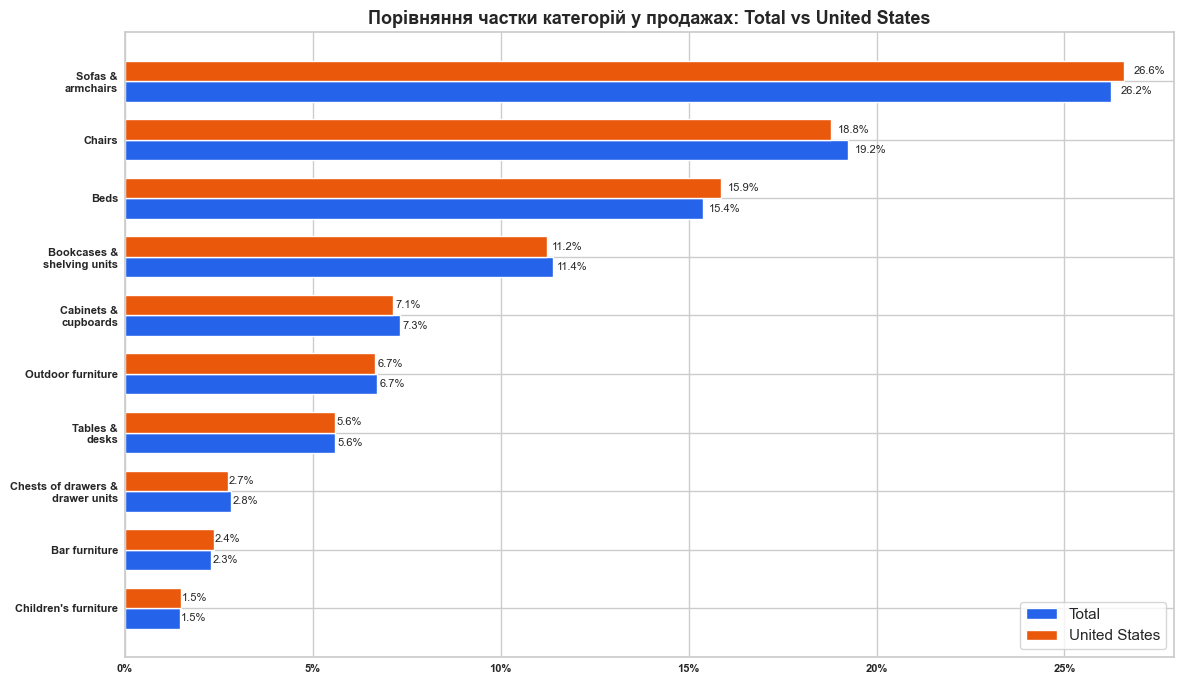

In [220]:
ORANGE = '#EA580C'
RED    = '#DC2626'

categories = top10_categories_global.index

global_percent = top10_categories_global.reindex(categories) / total_sales * 100
us_percent = top10_categories_us.reindex(categories) / us_total_sales * 100

categories = categories[::-1]
global_percent = global_percent[::-1]
us_percent = us_percent[::-1]

short_categories = [c.replace(' & ', ' &\n') for c in categories]

y = np.arange(len(categories))
height = 0.35

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

fig, ax = plt.subplots(figsize=(12, 7))

bars_global = ax.barh(y - height / 2, global_percent, height, color=ACCENT, label='Total')
bars_us = ax.barh(y + height / 2, us_percent, height, color=ORANGE, label='United States')

ax.set_yticks(y)
ax.set_yticklabels(short_categories)

ax.set_title('Порівняння частки категорій у продажах: Total vs United States', fontsize=13, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

ax.tick_params(axis='x', labelsize=8, pad=-1)
ax.tick_params(axis='y', labelsize=8, pad=-1)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')

for bar, val in zip(bars_global, global_percent):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

for bar, val in zip(bars_us, us_percent):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.legend()

plt.tight_layout()
plt.savefig('images/categories_percent_comparison.png', bbox_inches='tight')
plt.show()

 Ситуація в **United States** майже не відрізняється від загальної. Лідером і на загальному ринку, і в United States є категорія **Sofas & armchairs**: у загальних продажах її частка становить 26.2%, а в United States - 26.6%. Далі йдуть ті самі категорії: Chairs - 19.2% загалом і 18.8% у United States, Beds - 15.4% загалом і 15.9% у United States.

Загалом різниця між частками категорій у загальних продажах та продажах у United States є незначною: **максимальне** відхилення становить близько **0.5 відсотку**, а **мінімальне** — близько **0.1 відсотку**. Отже, **структура продажів у United States дуже схожа на загальну структуру продажів компанії**.

## 3. Пристрої та моделі девайсів

In [216]:
device_sales = df.groupby('device')['price'].sum().sort_values(ascending=False)
device_orders = df.groupby('device')['ga_session_id'].nunique().sort_values(ascending=False)

print('Продажі за типами пристроїв ($ та % від загальної суми):')
for index, (device, value) in enumerate(device_sales.items(), 1):
    print(f'{index}. {device:<10} ${value:>12,.0f} ({value / total_sales * 100:.1f}%)')

print('-'*80)
print()

print('Замовлення за типами пристроїв (кількість та % від загальної кількості):')
for i, (device, value) in enumerate(device_orders.items(), 1):
    print(f'{i}. {device:<10} {value:>10,} замовлень ({value / unique_sessions * 100:.1f}%)')

print('-'*80)
print()

df_mobile_tablet = df[df['device'].isin(['mobile', 'tablet'])]

model_sales = df_mobile_tablet.groupby('mobile_model_name')['price'].sum().sort_values(ascending=False).head(5)
model_orders = df_mobile_tablet.groupby('mobile_model_name')['ga_session_id'].nunique().sort_values(ascending=False).head(5)

print('Топ-5 моделей пристроїв (mobile + tablet) за продажами (% від загальної суми):')
for index, (model, value) in enumerate(model_sales.items(), 1):
    print(f'{index}. {model:<15} ${value:>10,.0f} ({value / total_sales * 100:.1f}%)')

print('-'*80)
print()

print('Топ-5 моделей пристроїв (mobile + tablet) за замовленнями (% від загальної кількості):')
for index, (model, value) in enumerate(model_orders.items(), 1):
    print(f'{index}. {model:<15} {value:>8,} замовлень ({value / unique_sessions * 100:.1f}%)')

Продажі за типами пристроїв ($ та % від загальної суми):
1. desktop    $  18,864,039 (59.0%)
2. mobile     $  12,384,226 (38.7%)
3. tablet     $     723,466 (2.3%)
--------------------------------------------------------------------------------

Замовлення за типами пристроїв (кількість та % від загальної кількості):
1. desktop        19,702 замовлень (58.7%)
2. mobile         13,113 замовлень (39.1%)
3. tablet            723 замовлень (2.2%)
--------------------------------------------------------------------------------

Топ-5 моделей пристроїв (mobile + tablet) за продажами (% від загальної суми):
1. iPhone          $ 6,420,776 (20.1%)
2. <Other>         $ 6,009,686 (18.8%)
3. iPad            $   448,854 (1.4%)
4. Pixel 4 XL      $   118,288 (0.4%)
5. Pixel 3         $   109,148 (0.3%)
--------------------------------------------------------------------------------

Топ-5 моделей пристроїв (mobile + tablet) за замовленнями (% від загальної кількості):
1. iPhone             6,819 зам

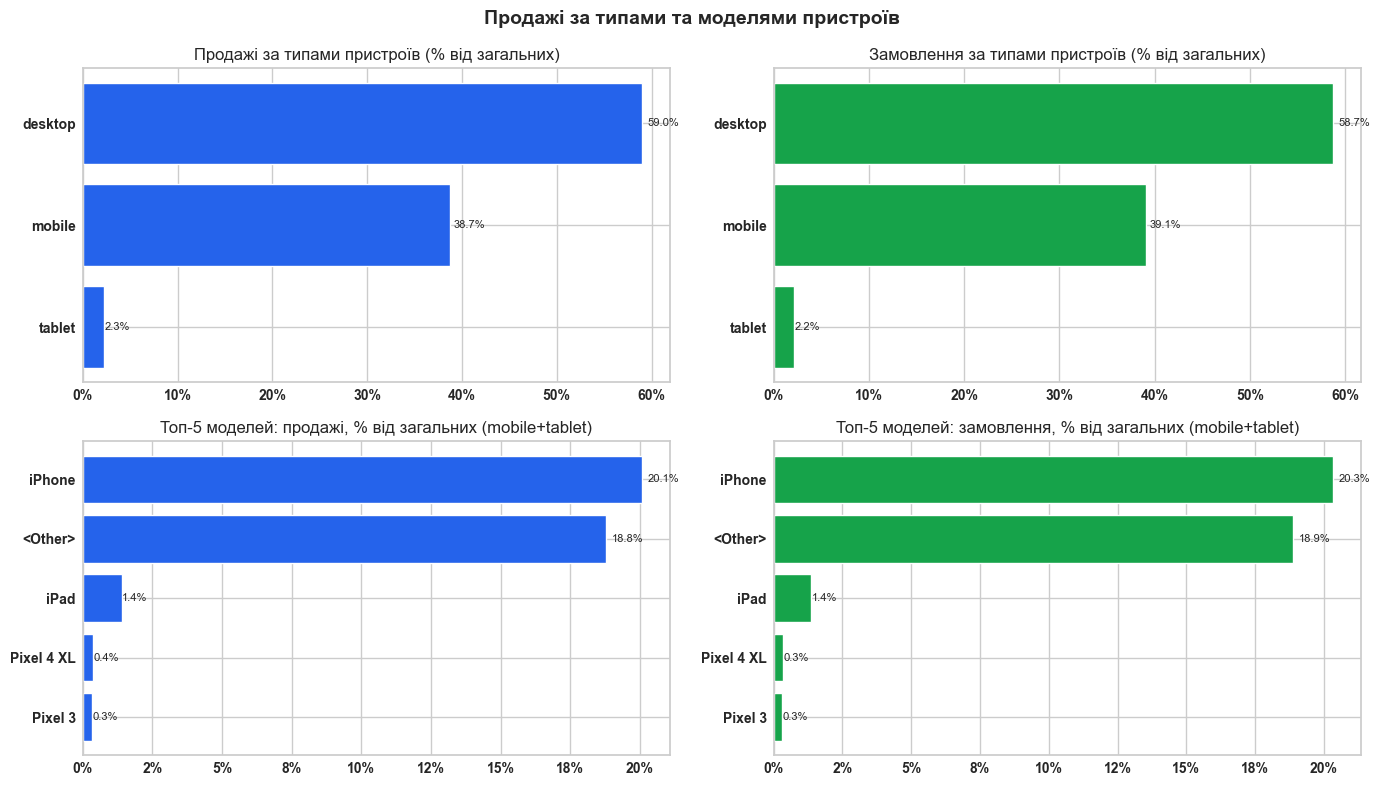

In [221]:
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

device_sales_percent  = device_sales  / total_sales    * 100
device_orders_percent = device_orders / unique_sessions * 100
model_sales_percent   = model_sales   / total_sales    * 100
model_orders_percent  = model_orders  / unique_sessions * 100

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Продажі за типами та моделями пристроїв', fontsize=14, fontweight='bold', y=0.98)

pct_fmt = mticker.FuncFormatter(lambda x, _: f'{x:.0f}%')


def annotate_bars(ax, bars, values, fmt='{:.1f}%'):
    for bar, val in zip(bars, values):
        ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                fmt.format(val), va='center', fontsize=8)


def style_ax(ax):
    ax.tick_params(axis='x', labelsize=10, pad=-1)
    ax.tick_params(axis='y', labelsize=10, pad=-1)
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.xaxis.set_major_formatter(pct_fmt)


# продажі за типами пристроїв
ax = axes[0, 0]
bars = ax.barh(device_sales_percent.index[::-1], device_sales_percent.values[::-1], color=ACCENT)
ax.set_title('Продажі за типами пристроїв (% від загальних)')
style_ax(ax)
annotate_bars(ax, bars, device_sales_percent.values[::-1])

# замовлення за типами пристроїв
ax = axes[0, 1]
bars = ax.barh(device_orders_percent.index[::-1], device_orders_percent.values[::-1], color=GREEN)
ax.set_title('Замовлення за типами пристроїв (% від загальних)')
style_ax(ax)
annotate_bars(ax, bars, device_orders_percent.values[::-1])

# продажі за моделями (mobile + tablet)
ax = axes[1, 0]
bars = ax.barh(model_sales_percent.index[::-1], model_sales_percent.values[::-1], color=ACCENT)
ax.set_title('Топ-5 моделей: продажі, % від загальних (mobile+tablet)')
style_ax(ax)
annotate_bars(ax, bars, model_sales_percent.values[::-1])

# замовлення за моделями (mobile + tablet)
ax = axes[1, 1]
bars = ax.barh(model_orders_percent.index[::-1], model_orders_percent.values[::-1], color=GREEN)
ax.set_title('Топ-5 моделей: замовлення, % від загальних (mobile+tablet)')
style_ax(ax)
annotate_bars(ax, bars, model_orders_percent.values[::-1])

plt.tight_layout()
plt.savefig('images/sales_by_device_type_model.png', bbox_inches='tight')
plt.show()

**Висновок:** основним каналом продажів є **desktop**. Це **59.0%** загальної суми продажів та **58.7%** усіх замовлень. Частка **mobile** - **38.7%** продажів і **39.1%** замовлень, що свідчить про суттєву мобільну аудиторію. **Tablet** займає лише **2.3%** продажів і **2.2%** замовлень і це мінімальний сегмент. Важливо, що відсотки продажів та замовлень по кожному типу пристрою майже збігаються, тобто середній чек не залежить від типу пристрою.

Серед моделей мобільних пристроїв (mobile + tablet) лідером є **iPhone** з часткою **20.1%** від загальних продажів та **20.3%** від замовлень. Практично рівну позицію займають всі пристрої які зараховані в цьому датасету до **\<Other\>** - **18.8%** продажів і **18.9%** замовлень. Ця категорія об'єднує Android-пристрої, які GA4 не зміг ідентифікувати за конкретною моделлю. Разом iPhone та \<Other\> формують **38.9%** загальних продажів - тобто майже весь мобільний трафік.

**iPad** посідає третє місце з часткою **1.4%** як у продажах, так і в замовленнях. Пристрої на базі Android, які вдалося ідентифікувати (**Pixel 4 XL** та **Pixel 3**), мають мінімальний вплив - **0.4%** і **0.3%** відповідно.

Отже, попри домінування desktop, мобільна аудиторія формує майже **40% продажів**. Серед мобільних пристроїв переважає iOS-екосистема (**iPhone + iPad = 21.5%** від загальних продажів), тоді як ідентифіковані Android-пристрої займають менше **1%**.